# Score function and score based models

From https://yang-song.net/blog/2021/score/ <br>

Suppose to have a dataset made of $\{\bold{x_1}, \bold{x_2}, ..., \bold{x_n}\}$ samples drawn from an underlying distribution $p(\bold{x})$. Given this dataset, the objective is to find a model that can fit the data distribution in order to synthetize new data points. <br>
A way to represent a propability distribution is by modelling directly its probability density function (pdf). Let $f_{theta}(\bold{x}) \in \mathbb{R}$ be a real-valued function parametrized by a learnable paramenter $\theta$. Such pdf can be defined as an **energy based model**:
$$ p_{\theta}(\bold{x}) = \frac{\exp(-f_{\theta}({\bold{x}}))}{\bold{Z}_{\theta}}  $$

Where $\bold{Z}_{\theta} > 0$ is a normalizing constant depending on $\theta$, such that $\int{p_{\theta}(\bold{x})dx} = 1$. This is a Gibbs distribution and so the function $f_{theta}(\bold{x})$ is called an energy function. <br>
Normally, we can train $p_{\theta}(\bold{x})$ by maximizing the log-likelihood but this gives problems as the normalizing function $\bold{Z}_{\theta}$ in unknown. <br>

On the other hand, we can model the score function instead of the density function and sidestep the difficulty of intractable normalizing constants. The score function of a distribution $p(\bold{x})$ is defined as:
$$  \nabla_{x}{log [p(\bold{x}) ] } $$

A model for the score function is called **score-based model** and we denote it as $s_{\theta}(\bold{x})$. <br>
The score-based model is learned such that $s_{\theta}(\bold{x}) \approx  \nabla_{x}{log [p(\bold{x}) ] }$ and for the case of the energy based model:

$$ s_{\theta}(\bold{x}) = \nabla_{x}{log [p_{\theta}(\bold{x}) ] } = - \nabla_{x}{f_{\theta}(\bold{x}) } - \nabla_{x}{ \bold{Z}_{\theta} } = - \nabla_{x}{f_{\theta}(\bold{x}) } $$

Similar to likelihood-based models, we can train score-based models by minimizing the **Fisher divergence** between the model and the data distribution:
$$ \mathbb{E}_{p(\bold{x})} [\|\nabla_{x}{log [p(\bold{x}) ]} - s_{\theta}(\bold{x}) \|_{2}^{2}] $$

Intuitively, the Fisher divergence compares the squared L2 distance betweeen the ground-truth data scoer and the score-based model.<br> 
Directly computing this divergence is unfeasible as is required the access to the distribution generating the data $p(\bold{x})$ to compute its gradient. However there exist a family of methods called **score matching** that minimize the Fisher divergence withouth the knowledge of the ground truth data score.

Additionally, using the score matching objective gives us a considerable amount of modeling flexibility. The Fisher divergence itself does not require $s_{\theta}(\bold{x})$
 to be an actual score function of any normalized distribution, it simply compares the L2
 distance between the ground-truth data score and the score-based model, with no additional assumptions on the form of  $s_{\theta}(\bold{x})$. 
 In fact, the only requirement on the score-based model is that it should be a vector-valued function with the same input and output dimensionality, which is easy to satisfy in practice.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_swiss_roll

np.random.seed(42)
torch.random.manual_seed(42)

# Generate Swiss roll dataset
def generate_swiss_roll(n_samples=1000, noise=0.1):
    data, _ = make_swiss_roll(n_samples, noise=noise)
    return data[:, [0, 2]] / 10.0  # Take only two dimensions

n_samples = 1000
data = generate_swiss_roll(n_samples)

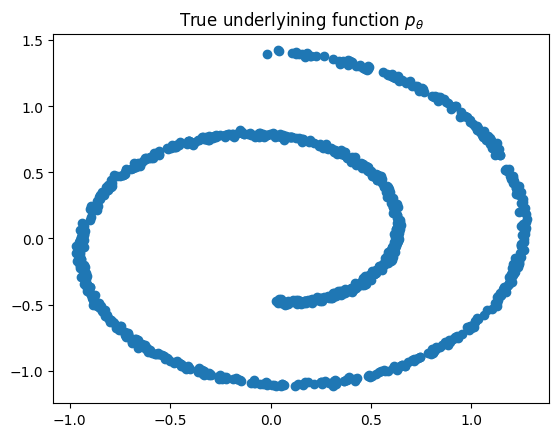

In [3]:
plt.clf()
plt.scatter(data[:,0], data[:,1])
plt.title(r"True underlyining function $ p_{\theta} $")
plt.show()

### Langevin dynamics
Once a score-based model has trained, so that $s_{\theta}(\bold{x}) \approx  \nabla_{x}{log [p(\bold{x}) ] }$, an iterative procedure called **Langevin dynamics** can be used to draw samples. <br>
This provides a Monte-Carlo Markov chain procedure to sample from a distribution $p(\bold{x})$ using only its score function $\nabla_{x}{log [p(\bold{x})]}$. Specifically, it initializes the chain form an arbitrary prior distribution $x_0 \sim \pi(\bold{x})$ and iterates the following formula:
$$ x_{i+1} <- x_{i}  + \epsilon \nabla_{x}{log [p(\bold{x}) ]} + \sqrt{2\epsilon} \bold{z}_i  $$
for $i=0,1..,K$ and where $\bold{z}_i \sim N(0,I)$.
In practice, the error is negligible when $K$ is high and $\epsilon$ is small. <br>
Note that the Langevin dynamic acesses $p(\bold{x})$ only through $\nabla_{x}{log [p(\bold{x})]}$. So if we trained a score function that s_{\theta}(\bold{x}) \approx  \nabla_{x}{log [p(\bold{x}) ] }$, than we can use such score function to produce a Langevin dynamic and produce new samples

In [4]:
# Sampling using Langevin dynamics
def sample_langevin(model, n_samples=1000, steps=5000, epsilon=0.005):
    # prior initialization
    x = torch.randn(n_samples, 2) * 2  
    for _ in range(steps):
        z = torch.randn_like(x) * np.sqrt(epsilon * 2)
        score = model(x).detach()
        x = x + epsilon * score + z
    return x.numpy()

### Score-based generative modeling with multiple noise perturbations

We saw previously that to train the score function it can be used the Fisher divergence:

$$ \mathbb{E}_{p(\bold{x})} [\|\nabla_{x}{log [p(\bold{x}) ]} - s_{\theta}(\bold{x}) \|_{2}^{2}] = \int{p(\bold{x}) \|\nabla_{x}{log [p(\bold{x}) ]} - s_{\theta}(\bold{x}) \|_{2}^{2} dx } $$

There are ways to re-write this function to cancel the dependecy on $\nabla_{x}{log [p(\bold{x}) ]}$ (which is unknown) and actually train the model. This however resulted in low success. <br>

The main reason for that is the fact that the estimated score functions are inaccurate in low density regions, 
where few data points are available for computing the score matching objective. 
This is expected as score matching minimizes the Fisher divergence 
Since the L2 differences between the true data score function and score-based model are weighted by $p(\bold{x})$, they are largely ignored in low density regions where $p(\bold{x})$ is small as suggested by the image below.

<div>
<img src="imgs/pitfalls.jpg" width="1000"/>
</div>

### Adding noise perturbation

To bypass the difficulty of accurate score estimation in regions of low data density, a solution is to perturb data points with noise and train score-based models on the noisy data points instead. When the noise magnitude is sufficiently large, it can populate low data density regions to improve the accuracy of estimated scores. <br>

Yet another question remains: how do we choose an appropriate noise scale for the perturbation process? Larger noise can obviously cover more low density regions for better score estimation, but it over-corrupts the data and alters it significantly from the original distribution. Smaller noise, on the other hand, causes less corruption of the original data distribution, but does not cover the low density regions as well as we would like.

To achieve the best of both worlds, we use multiple scales of noise perturbations simultaneously. <br>
Suppose we always perturb the data with isotropic Gaussian noise, and let there be a total of  increasing standard deviations $\sigma_1 < \sigma_2 < ...<\sigma_L$. We first perturb the data distribution $p(\bold{x})$ with each of the Gaussian noise $N(0,\sigma_{i}^2I)$ with $i=1,2,..,L$ to obtain a noise-perturbed distribution:
$$ p_{\sigma_i}(\bold{x}) = \int{p(\bold{y}) N(\bold{x}; \bold{y}, \sigma_{i}^2I) d\bold{y}} $$

And draw samples from $p_{\sigma_i}(\bold{x})$ is just sampling $\bold{x}$ from $p(\bold{x})$ and computing $\bold{x} + \sigma_i\bold{z}$ with $ z \sim N(0,I)$. <br>

Next, we estimate the score function of each noise-perturbed distribution (i.e., $\nabla_{x}{log [p_{\sigma_i}(\bold{x}) ]}$) by training a **Noise Conditional Score-Based Model** $s_{\theta}(\bold{x}, i)$ with score matching such that $s_{\theta}(\bold{x}, i) \approx \nabla_{x}{log [p_{\sigma_i}(\bold{x}) ]} $ for all noises $i=1,2,..., L$. <br>

Some points about this section:
* What is usually done in practice is to avoid to train a score-based model for each $\sigma_i$ but rather create one neural network which takes as input $\bold{x}$ and $\sigma_i$ it-self,  **Noise conditional score network**.
* The $\sigma_i$ are taken as a geometric progression from a $\sigma_1$ which can encompass the casistic in the data, to a $\sigma_L$ which is low (i.e., 0.001) and so the inject noise do not perturbe too much the data

In [5]:
class NoiseConditionalScoreNetwork(nn.Module):
    def __init__(self, in_dim, hidden_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim+1, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, in_dim)
        )
    
    def forward(self, x, sigma):
        return self.net(torch.cat([x,sigma], dim=-1))

### Annealed Langevin Dynamics for training
The training objective for $s_{\theta}(\bold{x})$ is a weighted sum sum of Fisher divergences for all nois scales. In particular the objective function is:
$$ \frac{1}{L} \sum_{i=1}^{L}{\lambda(i) \mathbb{E}_{p_{\sigma_i}(\bold{x})} [\|\nabla_{x}{log [p_{sigma_i}(\bold{x}) ]} - s_{\theta}(\bold{x},i) \|_{2}^{2}] } $$
where $\lambda(i)$ is chosen as $lambba(i) = \sigma_i^2$

Now, if the noise we are injecting is coming from a normal disttribution, it can be demonstrated that the objective function can be estimated as (ref. https://www.youtube.com/watch?v=E69Lp_T9nVg&list=PLoROMvodv4rPOWA-omMM6STXaWW4FvJT8&index=14):

$$ \frac{1}{L} \sum_{i=1}^{L}{\lambda(i) \mathbb{E}_{\bold{x}\sim p_{data}, \bold{z} \sim N(0,I)} [\|s_{\theta}(\bold{x},i) + \frac{\bold{z}}{\sigma_i} \|_{2}^{2}] } $$



In [6]:
def geometric_progression(first, last, n):
    r = (last / first) ** (1 / (n - 1))
    return [first * r**i for i in range(n)]

In [7]:
# Training parameters
lr = 1e-3
epochs = 10_000  # Increased epochs
batch_size = 128
data = generate_swiss_roll(n_samples)
data = torch.tensor(data, dtype=torch.float32)

sigmas = np.array( geometric_progression(2, 0.05, 100) )

In [8]:
dataloader = torch.utils.data.DataLoader(data, batch_size=batch_size, shuffle=True)
model = NoiseConditionalScoreNetwork(in_dim=2, hidden_dim=128)
optimizer = optim.Adam(model.parameters(), lr=lr)

In [9]:
for epoch in range(epochs):
    total_loss = 0
    for batch in dataloader:
        sampled_sigmas = torch.tensor(sigmas[ np.random.randint(0, len(sigmas)-1, batch.shape[0]) ], dtype=torch.float32 ).unsqueeze(1)
        z = sampled_sigmas * torch.randn_like(batch)

        noisy_batch = batch + z
        score = z / sampled_sigmas**2
        predicted_score = model(noisy_batch, sampled_sigmas)
        
        loss = ((sampled_sigmas**2) * (predicted_score + score) ** 2).mean()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    if epoch % 1_000 == 0:
        print(f"Epoch {epoch}, Loss: {total_loss / len(dataloader):.4f}")
        
print(f"Epoch {epoch}, Loss: {total_loss / len(dataloader):.4f}")

Epoch 0, Loss: 0.8523
Epoch 1000, Loss: 0.5639
Epoch 2000, Loss: 0.5562
Epoch 3000, Loss: 0.5141
Epoch 4000, Loss: 0.4738
Epoch 5000, Loss: 0.4932
Epoch 6000, Loss: 0.5305
Epoch 7000, Loss: 0.4565
Epoch 8000, Loss: 0.4779
Epoch 9000, Loss: 0.5314
Epoch 9999, Loss: 0.4655


In [10]:
# Sampling using Langevin dynamics
def sample_langevin(model, prior, sigma, step_size, steps=5000,):
    # prior initialization
    x = prior #torch.randn(n_samples, 2) * 2  
    sigma = torch.tensor(sigma, dtype=torch.float32).repeat(prior.shape[0]).unsqueeze(1)
    for _ in range(steps):
        z =  torch.randn_like(x) * np.sqrt(step_size)
        score = model(x, sigma).detach()
        x = x + step_size/2 * score + z
    return x.numpy()

In [11]:
prior = torch.randn( n_samples, 2 ) 
epsilon=0.001
for i, sigma in enumerate(sigmas):    
    step_size = epsilon * sigma**2/sigmas[-1]**2
    x = sample_langevin(model, prior, sigma, step_size, steps=1_000)
    prior = torch.tensor(x)

<Figure size 640x480 with 0 Axes>

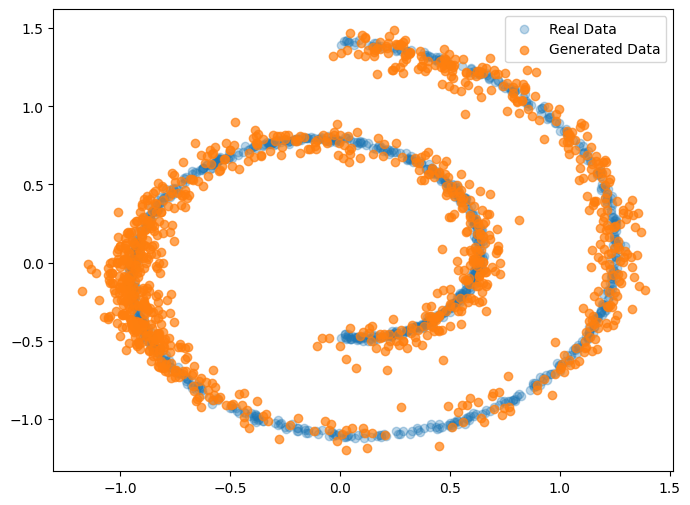

In [12]:
# Generate and plot samples
plt.clf()
plt.figure(figsize=(8, 6))
plt.scatter(data[:, 0], data[:, 1], alpha=0.3, label="Real Data")
plt.scatter(x[:, 0], x[:, 1], alpha=0.7, label="Generated Data")
plt.legend()
plt.show()

<Figure size 640x480 with 0 Axes>

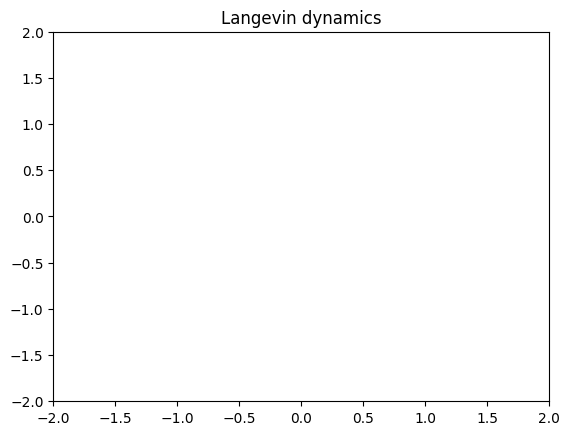

<Figure size 800x600 with 0 Axes>

In [15]:
import matplotlib.animation as animation
plt.clf()
fig, ax = plt.subplots()
plt.figure(figsize=(8, 6))

ims = []
prior = torch.randn(n_samples, 2) 
for i, sigma in enumerate(sigmas):    
    step_size = epsilon * sigma**2/sigmas[-1]**2
    x = sample_langevin(model, prior, sigma, step_size, steps=1_000)
    prior = torch.tensor(x)

    # Generate and plot samples
    p1 = ax.scatter(data[:, 0], data[:, 1], alpha=0.3, label="Real Data", color="blue")
    p2 = ax.scatter(x[:, 0], x[:, 1], alpha=0.7, label="Generated Data", color="orange")
    p3 = ax.text(0.02, 0.95, 'Sigma = %1.3f' % sigma, transform=ax.transAxes)
    p4 = ax.text(0.02, 0.90, 'iteration = %2.0f J' % i, transform=ax.transAxes)

    ims.append([p1,p2,p3, p4])


ax.set_xlim([-2,2])
ax.set_ylim([-2,2])

ax.set_title('Langevin dynamics')

ani = animation.ArtistAnimation(fig, ims, interval=50, blit=True)

In [16]:
ani.save('swiss_roll.mp4')